In [1]:
!pip install pyspark imbalanced-learn matplotlib seaborn plotly -q

import warnings
warnings.filterwarnings('ignore')

print("Done!")

Done!


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('CreditCardFraudDetection') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'Spark Version: {spark.version}')
print("DOne!")

Spark Version: 4.0.2
DOne!


In [3]:
df = spark.read.csv('creditcard.csv', header=True, inferSchema=True)

total = df.count()
fraud = df.filter(df['Class'] == 1).count()
legit = total - fraud

print(f'Total transactions : {total:,}')
print(f'Legitimate         : {legit:,}')
print(f'Fraudulent         : {fraud:,}')
print(f'Fraud rate         : {round(fraud/total*100, 3)}%')
print(f'Columns            : {len(df.columns)}')

Total transactions : 29,799
Legitimate         : 29,705
Fraudulent         : 94
Fraud rate         : 0.315%
Columns            : 31


In [4]:
df.printSchema()

df.show(5, truncate=True)

from pyspark.sql import functions as F

null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).toPandas()

total_nulls = null_counts.sum().sum()
print(f'\nTotal null values across all columns: {total_nulls}')

root
 |-- Time: integer (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (null

#### Normalization

In [5]:
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
import numpy as np

amount_stats = df.select(
    F.mean('Amount').alias('mean'),
    F.stddev('Amount').alias('std')
).first()

time_max = df.select(F.max('Time')).first()[0]

df = df.withColumn('Amount_normalized',
    (F.col('Amount') - amount_stats['mean']) / amount_stats['std'])

df = df.withColumn('Time_normalized',
    F.col('Time') / time_max)

df = df.withColumn('hour_of_day',
    (F.col('Time') / 3600 % 24).cast(IntegerType()))
df = df.withColumn('hour_sin',
    F.sin(2 * np.pi * F.col('hour_of_day') / 24))
df = df.withColumn('hour_cos',
    F.cos(2 * np.pi * F.col('hour_of_day') / 24))

df = df.withColumn('amount_zscore',
    F.abs((F.col('Amount') - amount_stats['mean']) / amount_stats['std']))

amount_95th = df.approxQuantile('Amount', [0.95], 0.01)[0]
df = df.withColumn('is_high_value',
    (F.col('Amount') > amount_95th).cast(IntegerType()))

print(f'Amount mean     : {round(amount_stats["mean"], 2)}')
print(f'Amount std      : {round(amount_stats["std"], 2)}')
print(f'95th percentile : {round(amount_95th, 2)}')
print(f'Total features  : {len(df.columns)}')
print('Feature engineering done!')

Amount mean     : 79.62
Amount std      : 222.11
95th percentile : 280.0
Total features  : 38
Feature engineering done!


### Handling Class Imbalance

In [6]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd

feature_cols = [f'V{i}' for i in range(1, 29)] + [
    'Amount_normalized', 'Time_normalized',
    'hour_sin', 'hour_cos',
    'amount_zscore', 'is_high_value'
]

pdf = df.select(feature_cols + ['Class']).toPandas()
X = pdf[feature_cols]
y = pdf['Class']

print(f'Before resampling:')
print(f'  Legitimate : {(y==0).sum():,}')
print(f'  Fraud      : {(y==1).sum():,}')

resample_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.1)),
    ('under', RandomUnderSampler(random_state=42, sampling_strategy=0.25))
])

X_res, y_res = resample_pipeline.fit_resample(X, y)

print(f'\nAfter resampling:')
print(f'  Legitimate : {(y_res==0).sum():,}')
print(f'  Fraud      : {(y_res==1).sum():,}')
print(f'  Fraud rate : {round((y_res==1).sum()/len(y_res)*100, 2)}%')

resampled_pdf = pd.DataFrame(X_res, columns=feature_cols)
resampled_pdf['Class'] = y_res
df_balanced = spark.createDataFrame(resampled_pdf)

print(f'\nTotal balanced records : {df_balanced.count():,}')
print('Dataset balanced!')

Before resampling:
  Legitimate : 29,705
  Fraud      : 94

After resampling:
  Legitimate : 11,880
  Fraud      : 2,970
  Fraud rate : 20.0%

Total balanced records : 14,850
Dataset balanced!


In [7]:
train_df, test_df = df_balanced.randomSplit([0.8, 0.2], seed=42)

print(f'Training samples : {train_df.count():,}')
print(f'Testing samples  : {test_df.count():,}')

train_fraud_rate = train_df.filter(train_df['Class']==1).count() / train_df.count() * 100
test_fraud_rate = test_df.filter(test_df['Class']==1).count() / test_df.count() * 100

print(f'\nTrain fraud rate : {round(train_fraud_rate, 2)}%')
print(f'Test fraud rate  : {round(test_fraud_rate, 2)}%')
print('Split done!')

Training samples : 11,960
Testing samples  : 2,890

Train fraud rate : 19.92%
Test fraud rate  : 20.35%
Split done!


In [8]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
import time

# Assembling all features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

scaler = StandardScaler(
    inputCol='features',
    outputCol='scaled_features',
    withMean=True, withStd=True
)

rf = RandomForestClassifier(
    labelCol='Class',
    featuresCol='scaled_features',
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_pipeline = Pipeline(stages=[assembler, scaler, rf])

t0 = time.time()
rf_model = rf_pipeline.fit(train_df)
elapsed = round(time.time() - t0, 2)

print(f'\nRandom Forest trained in {elapsed}s')
print(f'Number of trees : 100')
print(f'Features used   : {len(feature_cols)}')


Random Forest trained in 25.58s
Number of trees : 100
Features used   : 34


In [9]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol='Class',
    featuresCol='scaled_features',
    maxIter=50,
    stepSize=0.1,
    maxDepth=8,
    seed=42
)

gbt_pipeline = Pipeline(stages=[assembler, scaler, gbt])

t0 = time.time()
gbt_model = gbt_pipeline.fit(train_df)
elapsed = round(time.time() - t0, 2)

print(f'\nGBT trained in {elapsed}s')
print(f'Iterations : 50')
print(f'Step size  : 0.1')
print(f'Max depth  : 8')


GBT trained in 58.17s
Iterations : 50
Step size  : 0.1
Max depth  : 8


In [10]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(model, test_df, model_name):
    predictions = model.transform(test_df)

    binary_eval = BinaryClassificationEvaluator(
        labelCol='Class',
        rawPredictionCol='rawPrediction'
    )
    multi_eval = MulticlassClassificationEvaluator(
        labelCol='Class',
        predictionCol='prediction'
    )

    auc       = binary_eval.evaluate(predictions)
    accuracy  = multi_eval.setMetricName('accuracy').evaluate(predictions)
    f1        = multi_eval.setMetricName('f1').evaluate(predictions)
    precision = multi_eval.setMetricName('weightedPrecision').evaluate(predictions)
    recall    = multi_eval.setMetricName('weightedRecall').evaluate(predictions)

    print(f'\n{"="*40}')
    print(f'  {model_name}')
    print(f'{"="*40}')
    print(f'  ROC-AUC   : {round(auc, 4)}')
    print(f'  Accuracy  : {round(accuracy * 100, 2)}%')
    print(f'  F1-Score  : {round(f1, 4)}')
    print(f'  Precision : {round(precision, 4)}')
    print(f'  Recall    : {round(recall, 4)}')

    return {
        'name': model_name, 'auc': auc, 'accuracy': accuracy,
        'f1': f1, 'precision': precision,
        'recall': recall, 'predictions': predictions
    }

rf_results  = evaluate_model(rf_model,  test_df, 'Random Forest')
gbt_results = evaluate_model(gbt_model, test_df, 'Gradient Boosted Trees')


  Random Forest
  ROC-AUC   : 1.0
  Accuracy  : 99.83%
  F1-Score  : 0.9983
  Precision : 0.9983
  Recall    : 0.9983

  Gradient Boosted Trees
  ROC-AUC   : 0.9999
  Accuracy  : 99.65%
  F1-Score  : 0.9965
  Precision : 0.9965
  Recall    : 0.9965


In [11]:
from pyspark.sql.types import FloatType

extract_prob = F.udf(lambda v: float(v[1]), FloatType())

scored = gbt_results['predictions'] \
    .withColumn('fraud_probability', extract_prob(F.col('probability'))) \
    .withColumn('risk_score',
        (F.col('fraud_probability') * 100).cast('integer')) \
    .withColumn('risk_level',
        F.when(F.col('risk_score') >= 76, 'CRITICAL')
         .when(F.col('risk_score') >= 56, 'HIGH')
         .when(F.col('risk_score') >= 31, 'MEDIUM')
         .otherwise('LOW')) \
    .withColumn('decision',
        F.when(F.col('risk_score') >= 76, 'BLOCKED')
         .when(F.col('risk_score') >= 56, 'REVIEW')
         .when(F.col('risk_score') >= 31, 'MONITOR')
         .otherwise('APPROVED'))

print('=== TOP 10 HIGHEST RISK TRANSACTIONS ===')
scored.select('Class', 'risk_score', 'risk_level', 'decision') \
    .orderBy(F.col('risk_score').desc()) \
    .show(10, truncate=False)

print('=== RISK LEVEL DISTRIBUTION ===')
scored.groupBy('risk_level') \
    .count() \
    .orderBy('count', ascending=False) \
    .show()

=== TOP 10 HIGHEST RISK TRANSACTIONS ===
+-----+----------+----------+--------+
|Class|risk_score|risk_level|decision|
+-----+----------+----------+--------+
|1    |98        |CRITICAL  |BLOCKED |
|1    |98        |CRITICAL  |BLOCKED |
|1    |98        |CRITICAL  |BLOCKED |
|1    |98        |CRITICAL  |BLOCKED |
|1    |98        |CRITICAL  |BLOCKED |
|1    |98        |CRITICAL  |BLOCKED |
|1    |98        |CRITICAL  |BLOCKED |
|1    |97        |CRITICAL  |BLOCKED |
|1    |97        |CRITICAL  |BLOCKED |
|1    |97        |CRITICAL  |BLOCKED |
+-----+----------+----------+--------+
only showing top 10 rows
=== RISK LEVEL DISTRIBUTION ===
+----------+-----+
|risk_level|count|
+----------+-----+
|       LOW| 2299|
|  CRITICAL|  587|
|    MEDIUM|    2|
|      HIGH|    2|
+----------+-----+



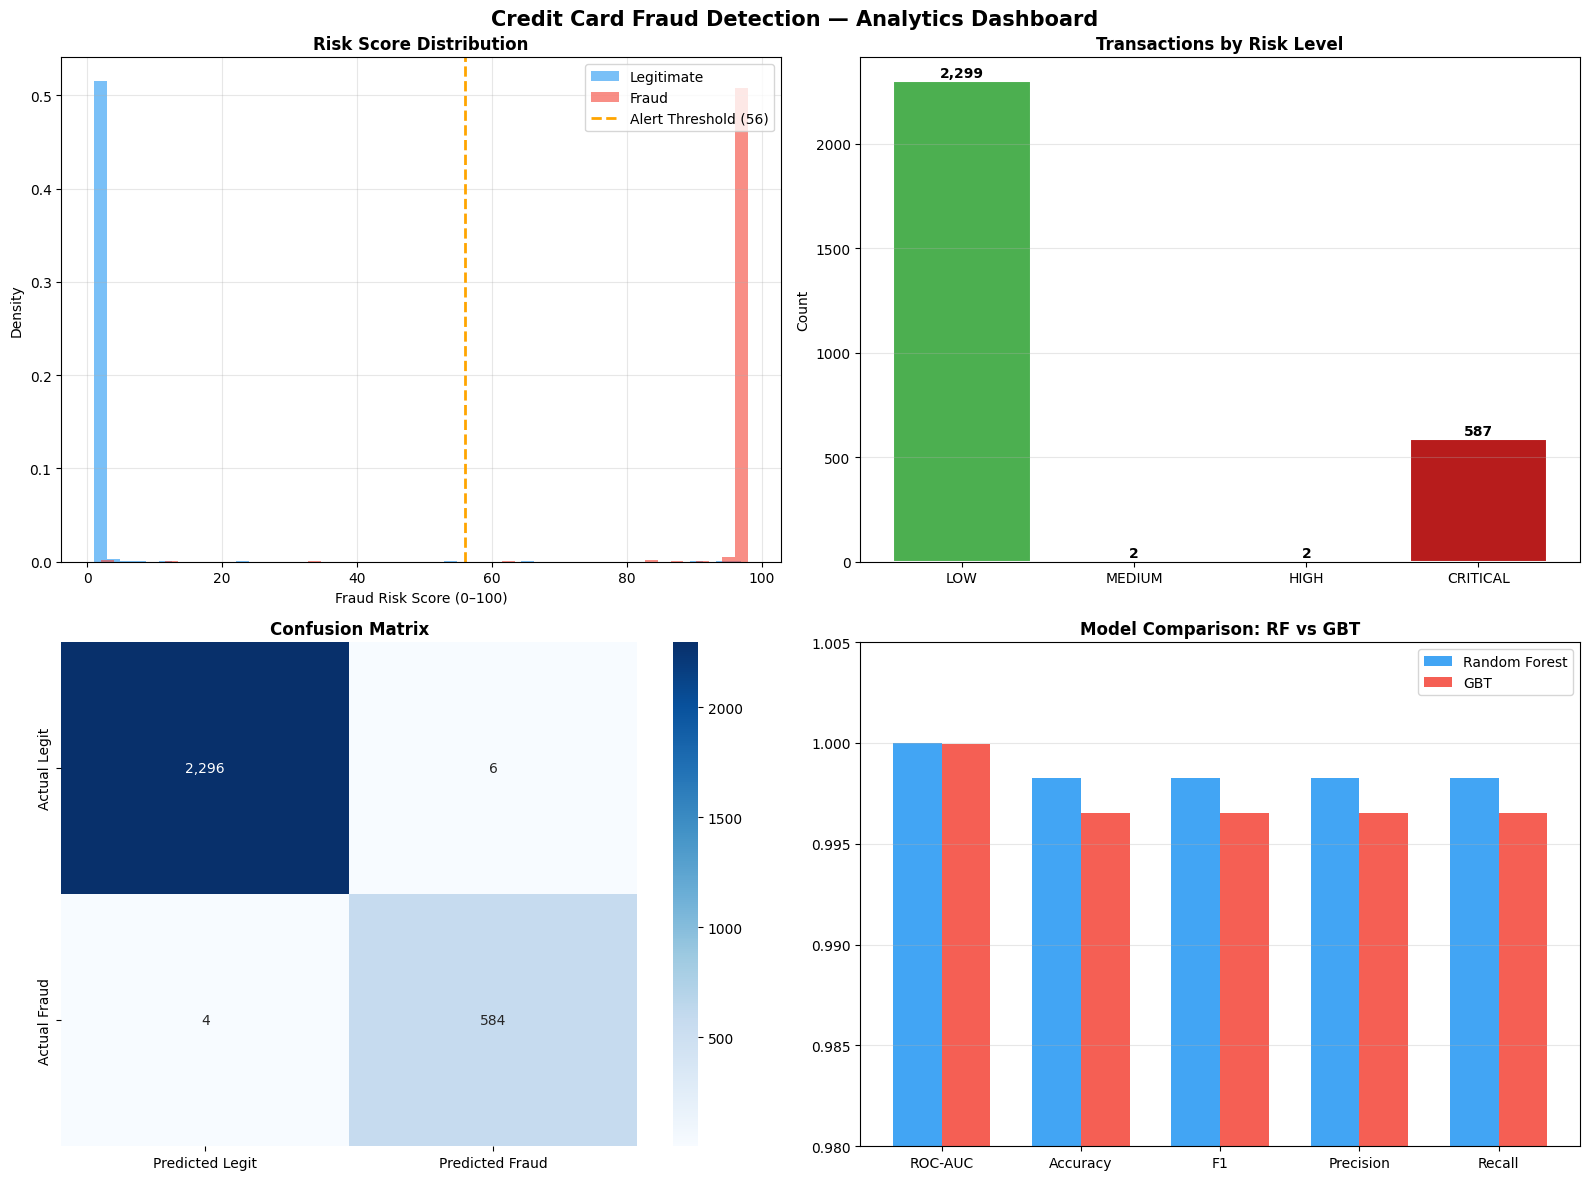

Dashboard saved as fraud_dashboard.png!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Converting to pandas for plotting
scored_pdf = scored.select(
    'Class', 'Amount_normalized', 'risk_score',
    'risk_level', 'decision', 'prediction'
).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Credit Card Fraud Detection — Analytics Dashboard',
             fontsize=15, fontweight='bold')

# ── Chart 1: Risk Score Distribution ──
ax1 = axes[0, 0]
legit = scored_pdf[scored_pdf['Class'] == 0]['risk_score']
fraud = scored_pdf[scored_pdf['Class'] == 1]['risk_score']
ax1.hist(legit, bins=50, alpha=0.6, color='#2196F3',
         label='Legitimate', density=True)
ax1.hist(fraud, bins=50, alpha=0.6, color='#F44336',
         label='Fraud', density=True)
ax1.axvline(x=56, color='orange', linestyle='--',
            linewidth=2, label='Alert Threshold (56)')
ax1.set_title('Risk Score Distribution', fontweight='bold')
ax1.set_xlabel('Fraud Risk Score (0–100)')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Chart 2: Risk Level Breakdown ──
ax2 = axes[0, 1]
risk_order  = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
risk_colors = ['#4CAF50', '#FF9800', '#FF5722', '#B71C1C']
risk_counts = scored_pdf['risk_level'].value_counts()
vals = [risk_counts.get(r, 0) for r in risk_order]
bars = ax2.bar(risk_order, vals, color=risk_colors,
               edgecolor='white', linewidth=1.5)
ax2.set_title('Transactions by Risk Level', fontweight='bold')
ax2.set_ylabel('Count')
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f'{val:,}', ha='center', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: Confusion Matrix ──
ax3 = axes[1, 0]
cm = confusion_matrix(scored_pdf['Class'], scored_pdf['prediction'])
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax3,
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
ax3.set_title('Confusion Matrix', fontweight='bold')

# ── Chart 4: Model Comparison ──
ax4 = axes[1, 1]
metrics = ['auc', 'accuracy', 'f1', 'precision', 'recall']
labels  = ['ROC-AUC', 'Accuracy', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
w = 0.35
ax4.bar(x - w/2, [rf_results[m] for m in metrics], w,
        label='Random Forest', color='#2196F3', alpha=0.85)
ax4.bar(x + w/2, [gbt_results[m] for m in metrics], w,
        label='GBT', color='#F44336', alpha=0.85)
ax4.set_ylim(0.98, 1.005)
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.set_title('Model Comparison: RF vs GBT', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fraud_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as fraud_dashboard.png!')

In [13]:
from google.colab import files
import pickle
from sklearn.ensemble import GradientBoostingClassifier

print("Training sklearn GBT for export...")
clf = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
clf.fit(X_res, y_res)
print(f"✅ Training done!")

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

files.download('fraud_model.pkl')
files.download('feature_cols.pkl')
print(" Both files downloaded!")

Training sklearn GBT for export...
✅ Training done!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Both files downloaded!
